# Matrix-Making Notebook

The purpose of this notebook is to create matrix-like figures that summarize accuracy of the model across various experiments run in climate_experiments.ipynb.

### Imports and File Stitching

In [12]:
# General Imports
import pandas as pd
import numpy as np
import os
import sys
import glob
import string

# Combinations
from itertools import combinations

# Plotting
import matplotlib.pyplot as plt

# ----File Stitching----
# If in climate_experiments folder, cd back to MamalakisResearch folder
if os.path.basename(os.getcwd()) == "climate_experiments":
    os.chdir('..')
# If a file is in /data_prep_viz/prep/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), '..', 'data_prep_viz/prep'))

### Read Files

In [14]:
# Read all csv files in climate_experiments folder
path = os.getcwd() + '/climate_experiments/'
csvs = glob.glob(os.path.join(path, "*.csv"))
summaries = []
for csv in csvs:
    df = pd.read_csv(csv)
    summaries.append(df)
summaries

[   scenario  early  late  mean_pred  accuracy
 0    ssp119   2015  2025   0.536047       0.5
 1    ssp119   2025  2035   0.562205       0.5
 2    ssp119   2035  2045   0.514703       0.5
 3    ssp119   2045  2055   0.585495       0.5
 4    ssp119   2055  2065   0.508485       0.5
 5    ssp119   2065  2075   0.623392       0.5
 6    ssp119   2075  2085   0.637004       0.5
 7    ssp126   2015  2025   0.565349       0.5
 8    ssp126   2025  2035   0.452607       0.5
 9    ssp126   2035  2045   0.527648       0.5
 10   ssp126   2045  2055   0.505105       0.5
 11   ssp126   2055  2065   0.582304       0.5
 12   ssp126   2065  2075   0.520834       0.5
 13   ssp126   2075  2085   0.456345       0.5]

### Calculations

In [24]:
# Calculate mean and standard deviation of accuracy between runs of the same experiment
def get_mean_std(summaries):
    # Make a df to hold: 
    # a) metadata
    acc_df = pd.DataFrame(columns=['scenario','early', 'late'])
    acc_df['scenario'] = summaries[0]['scenario']
    acc_df['early'] = summaries[0]['early']
    acc_df['late'] = summaries[0]['late']
    
    # b) accuracies
    for i in range(len(csvs)):
        acc_df[f"acc_{i}"] = summaries[i]['accuracy']
    
    # c) mean and std
    acc_cols = [col for col in acc_df.columns if col.startswith('acc_')]
    acc_df['mean'] = acc_df[acc_cols].mean(axis=1)
    acc_df['std'] = acc_df[acc_cols].std(axis=1)
    
    return acc_df

In [22]:
mean_std = get_mean_std(summaries)
mean_std.head()

,scenario,early,late,mean,std
0,ssp119,2015,2025,NaN,NaN
1,ssp119,2025,2035,NaN,NaN
2,ssp119,2035,2045,NaN,NaN
3,ssp119,2045,2055,NaN,NaN
4,ssp119,2055,2065,NaN,NaN


### Making a Matrix

In [6]:
# Make a copy
mean_std = mean_std.copy()
# Create the label pairings by changing scenario-early-late to a single, concatenated index
mean_std['label'] = mean_std['scenario'] + '_' + mean_std['early'].astype(str) + '_' + mean_std['late'].astype(str)
mean_std = mean_std.drop(columns=['scenario', 'early', 'late'])
# Drop the acc columns
mean_std = mean_std.drop(columns=[col for col in mean_std.columns if col.startswith('acc_')])
mean_std.set_index('label', inplace=True)
mean_std_119 = mean_std.filter(like='119', axis=0)
mean_std_126 = mean_std.filter(like='126', axis=0)
mean_std_119.head()

,mean,std
label,,
ssp119_2015_2025,NaN,NaN
ssp119_2025_2035,NaN,NaN
ssp119_2035_2045,NaN,NaN
ssp119_2045_2055,NaN,NaN
ssp119_2055_2065,NaN,NaN


Adapted from Max Pierini on Stack Overflow

Source - https://stackoverflow.com/a/66823998

Posted by Max Pierini, modified by community. See post 'Timeline' for change history

Retrieved 2026-04-13, License - CC BY-SA 4.0

In [7]:
def turn_into_matrix_df(mean_std_scenario):
    values = [a - b for a, b in combinations(mean_std_scenario['mean'], 2)]
    index = [f"{a} vs {b}" for a, b in combinations(mean_std_scenario.index, 2)]
    sr = pd.Series(values, index = index)
    
    df = sr.reset_index()
    df.columns = ['row_col', 'data']

    # Add missing values, will leave blank when actually plotting
    df_inv = pd.DataFrame({
        'row_col': [f"{b} vs {a}" for a, b in combinations(mean_std_scenario.index, 2)],
        'data': df.data * -1
        })
    
    df_values = pd.concat([df,df_inv])
    df_values[['row', 'col']] = df_values.row_col.str.split(' vs ', expand=True)

    df_piv = df_values[['row', 'col', 'data']].pivot(index='row', columns='col').fillna(0).astype(float)


    return df_piv

df_119 = turn_into_matrix_df(mean_std_119)
df_126 = turn_into_matrix_df(mean_std_126)
df_119

data                                    \
col              ssp119_2015_2025 ssp119_2025_2035 ssp119_2035_2045   
row                                                                   
ssp119_2015_2025              0.0              0.0              0.0   
ssp119_2025_2035              0.0              0.0              0.0   
ssp119_2035_2045              0.0              0.0              0.0   
ssp119_2045_2055              0.0              0.0              0.0   
ssp119_2055_2065              0.0              0.0              0.0   
ssp119_2065_2075              0.0              0.0              0.0   
ssp119_2075_2085              0.0              0.0              0.0   

                                                                     \
col              ssp119_2045_2055 ssp119_2055_2065 ssp119_2065_2075   
row                                                                   
ssp119_2015_2025              0.0              0.0              0.0   
ssp119_2025_2035              0.0              0.0              0.0   
ssp119_2035_2045              0.0              0.0              0.0   
ssp119_2045_2055              0.0              0.0              0.0   
ssp119_2055_2065              0.0              0.0              0.0   
ssp119_2065_2075              0.0              0.0              0.0   
ssp119_2075_2085              0.0              0.0              0.0   

                                   
col              ssp119_2075_2085  
row                                
ssp119_2015_2025              0.0  
ssp119_2025_2035              0.0  
ssp119_2035_2045              0.0  
ssp119_2045_2055              0.0  
ssp119_2055_2065              0.0  
ssp119_2065_2075              0.0  
ssp119_2075_2085              0.0

C:\Users\student\AppData\Local\Temp\ipykernel_51308\608294025.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['']+labels)
C:\Users\student\AppData\Local\Temp\ipykernel_51308\608294025.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['']+labels)


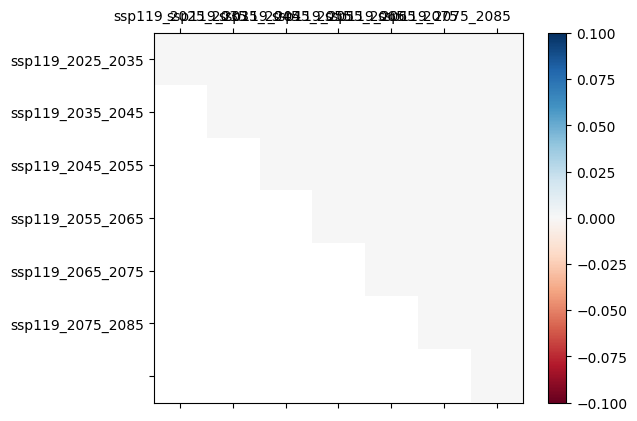

In [8]:
# Function to plot with colors and labels
def matshow_plot(df):
    labels = df.index
    data = df

    # Mask lower triangle
    mask = np.tril(np.ones_like(data), k=-1)
    data[mask == 1] = np.nan

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(data, interpolation='nearest', cmap='RdBu', vmin=-np.max(np.abs(data.values)), vmax=np.max(np.abs(data.values)))    
    fig.colorbar(cax)
    ax.set_xticklabels(['']+labels)
    ax.set_yticklabels(['']+labels)

    plt.show()

matshow_plot(df_119)